In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, make_scorer, log_loss, accuracy_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

## 1) LOAD DETAILED DATA

In [2]:
men_reg = pd.read_csv("data/MRegularSeasonDetailedResults.csv")
women_reg = pd.read_csv("data/WRegularSeasonDetailedResults.csv")
men_tour = pd.read_csv("data/MNCAATourneyDetailedResults.csv")
women_tour = pd.read_csv("data/WNCAATourneyDetailedResults.csv")

# Create a dictionary of datasets for easier iteration
datasets = {
    "Men Regular Season": men_reg,
    "Women Regular Season": women_reg,
    "Men Tournament": men_tour,
    "Women Tournament": women_tour
}

# Iterate through the datasets and display information
for name, dataset in datasets.items():
    print(f"{name} Data:")
    print(dataset.head())
    print(f"\n{name} Info:")
    print(dataset.info())
    print(f"\n{name} Summary:")
    print(dataset.describe())
    print("\n" + "-" * 50 + "\n")


Men Regular Season Data:
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  WFGA  \
0    2003      10     1104      68     1328      62    N      0    27    58   
1    2003      10     1272      70     1393      63    N      0    26    62   
2    2003      11     1266      73     1437      61    N      0    24    58   
3    2003      11     1296      56     1457      50    N      0    18    38   
4    2003      11     1400      77     1208      71    N      0    30    61   

   ...  LFGA3  LFTM  LFTA  LOR  LDR  LAst  LTO  LStl  LBlk  LPF  
0  ...     10    16    22   10   22     8   18     9     2   20  
1  ...     24     9    20   20   25     7   12     8     6   16  
2  ...     26    14    23   31   22     9   12     2     5   23  
3  ...     22     8    15   17   20     9   19     4     3   23  
4  ...     16    17    27   21   15    12   10     7     1   14  

[5 rows x 34 columns]

Men Regular Season Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11888

In [3]:
earliest_years = {
    "Men Regular Season": men_reg["Season"].min(),
    "Women Regular Season": women_reg["Season"].min(),
    "Men Tournament": men_tour["Season"].min(),
    "Women Tournament": women_tour["Season"].min()
}

for dataset, year in earliest_years.items():
    print(f"The earliest year in {dataset} is {year}.")

The earliest year in Men Regular Season is 2003.
The earliest year in Women Regular Season is 2010.
The earliest year in Men Tournament is 2003.
The earliest year in Women Tournament is 2010.


 **Insights:**
- To keep it consistant we will start from 2010 for all datasets.

In [4]:
# Keep data from 2010 onward, including partial 2025 if present
men_reg = men_reg[men_reg["Season"] >= 2010]
women_reg = women_reg[women_reg["Season"] >= 2010]
men_tour = men_tour[men_tour["Season"] >= 2010]
women_tour = women_tour[women_tour["Season"] >= 2010]

print("Men Regular Season shape:", men_reg.shape)
print("Women Regular Season shape:", women_reg.shape)
print("Men Tourney shape:", men_tour.shape)
print("Women Tourney shape:", women_tour.shape)

Men Regular Season shape: (84808, 34)
Women Regular Season shape: (81708, 34)
Men Tourney shape: (934, 34)
Women Tourney shape: (894, 34)


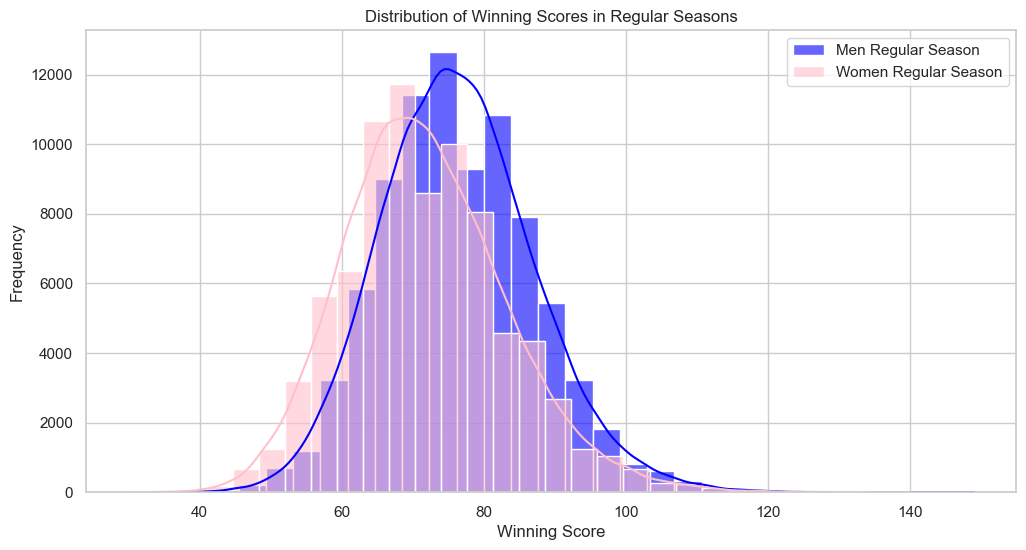

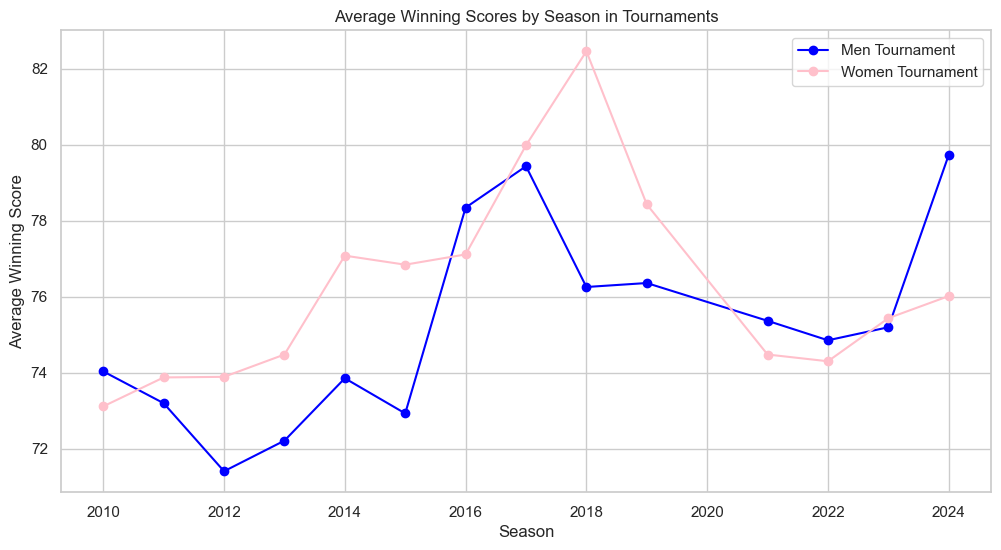

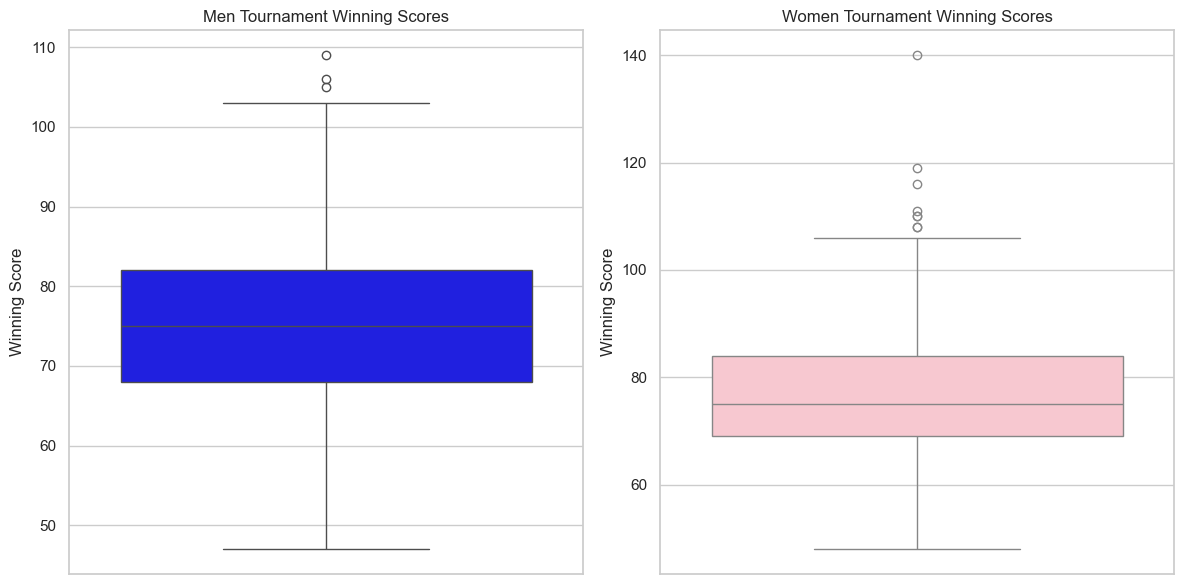

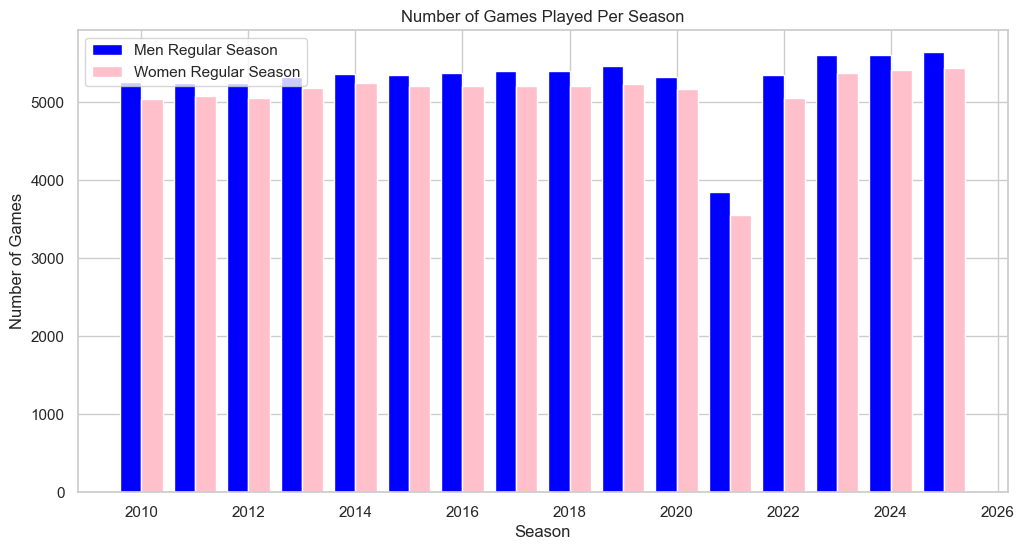

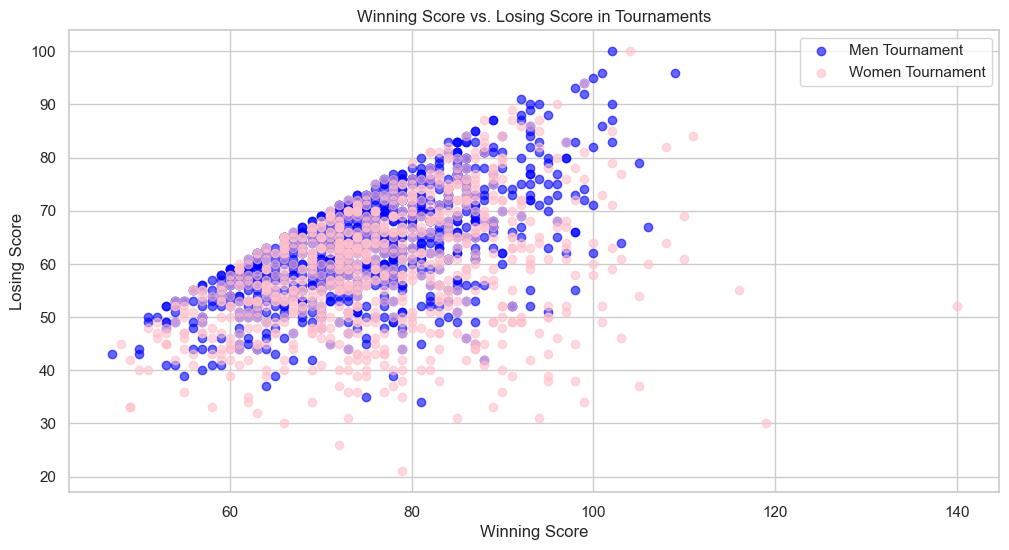

In [5]:
import seaborn as sns

import matplotlib.pyplot as plt

# Set the style for the plots
sns.set(style="whitegrid")

# Visualization 1: Distribution of scores in Men's and Women's Regular Seasons
plt.figure(figsize=(12, 6))
sns.histplot(men_reg['WScore'], bins=30, kde=True, color='blue', label='Men Regular Season', alpha=0.6)
sns.histplot(women_reg['WScore'], bins=30, kde=True, color='pink', label='Women Regular Season', alpha=0.6)
plt.title('Distribution of Winning Scores in Regular Seasons')
plt.xlabel('Winning Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Visualization 2: Average winning scores by season for Men's and Women's Tournaments
plt.figure(figsize=(12, 6))
men_avg_scores = men_tour.groupby('Season')['WScore'].mean()
women_avg_scores = women_tour.groupby('Season')['WScore'].mean()
plt.plot(men_avg_scores.index, men_avg_scores.values, label='Men Tournament', marker='o', color='blue')
plt.plot(women_avg_scores.index, women_avg_scores.values, label='Women Tournament', marker='o', color='pink')
plt.title('Average Winning Scores by Season in Tournaments')
plt.xlabel('Season')
plt.ylabel('Average Winning Score')
plt.legend()
plt.show()

# Visualization 3: Boxplot of scores in Men's and Women's Tournaments
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=men_tour['WScore'], color='blue')
plt.title('Men Tournament Winning Scores')
plt.ylabel('Winning Score')

plt.subplot(1, 2, 2)
sns.boxplot(y=women_tour['WScore'], color='pink')
plt.title('Women Tournament Winning Scores')
plt.ylabel('Winning Score')

plt.tight_layout()
plt.show()

# Visualization 4: Number of games played per season in Men's and Women's Regular Seasons
plt.figure(figsize=(12, 6))
men_games_per_season = men_reg['Season'].value_counts().sort_index()
women_games_per_season = women_reg['Season'].value_counts().sort_index()
plt.bar(men_games_per_season.index - 0.2, men_games_per_season.values, width=0.4, label='Men Regular Season', color='blue')
plt.bar(women_games_per_season.index + 0.2, women_games_per_season.values, width=0.4, label='Women Regular Season', color='pink')
plt.title('Number of Games Played Per Season')
plt.xlabel('Season')
plt.ylabel('Number of Games')
plt.legend()
plt.show()

# Visualization 5: Winning Score vs. Losing Score in Tournaments
plt.figure(figsize=(12, 6))
plt.scatter(men_tour['WScore'], men_tour['LScore'], alpha=0.6, color='blue', label='Men Tournament')
plt.scatter(women_tour['WScore'], women_tour['LScore'], alpha=0.6, color='pink', label='Women Tournament')
plt.title('Winning Score vs. Losing Score in Tournaments')
plt.xlabel('Winning Score')
plt.ylabel('Losing Score')
plt.legend()
plt.show()

### Insights from the Visualizations:

1. **Distribution of Winning Scores in Regular Seasons**:
    - The distribution of winning scores for both Men's and Women's Regular Seasons shows that Men's scores are slightly more concentrated around higher values compared to Women's scores.
    - This indicates that Men's games tend to have higher winning scores on average.

2. **Average Winning Scores by Season in Tournaments**:
    - Both Men's and Women's Tournament winning scores show an increasing trend over the years, with Men's scores generally being higher than Women's.
    - Notably, the Men's Tournament scores peaked around 2018, while Women's scores showed a significant increase in 2024.

3. **Boxplot of Winning Scores in Tournaments**:
    - The boxplots reveal that Men's Tournament scores have a slightly higher median and a narrower range compared to Women's scores.
    - This suggests that Men's games are more consistent in terms of scoring, while Women's games exhibit more variability.

4. **Number of Games Played Per Season**:
    - The number of games played per season is higher for Women's Regular Season compared to Men's.
    - Both Men's and Women's games saw a significant drop in 2021, likely due to external factors such as the COVID-19 pandemic.

5. **Winning Score vs. Losing Score in Tournaments**:
    - The scatter plot shows a positive correlation between winning and losing scores for both Men's and Women's Tournaments.
    - Men's games tend to cluster around higher scores, while Women's games show a wider spread, indicating more variability in scoring.

### Conclusion:
The analysis highlights key differences between Men's and Women's basketball data, with Men's games generally exhibiting higher and more consistent scores, while Women's games show greater variability and a larger number of games played per season.


### Step-by-Step Thought Process for Writing the Code

1. **Combine Men’s and Women’s Regular Season Data**:
    - Use `pd.concat` to merge `men_reg` and `women_reg` into a single DataFrame `reg_combined`.
    - This allows for unified processing of both datasets.

2. **Prepare Winner and Loser Perspective Data**:
    - Create two copies of `reg_combined`: `winner_cols` and `loser_cols`.
    - These will represent the game data from the perspective of the winning and losing teams, respectively.

3. **Engineer Columns for Winner Perspective**:
    - Add columns such as `TeamID`, `OpponentID`, `TeamScore`, `OpponentScore`, `TeamLoc`, and `Win` to `winner_cols`.
    - These columns standardize the data to represent the winning team’s perspective.

4. **Engineer Columns for Loser Perspective**:
    - Similarly, add the same columns to `loser_cols`, but from the losing team’s perspective.
    - Use a `loc_map` dictionary to map the location (`WLoc`) for the losing team.

5. **Select Relevant Columns**:
    - Define a list of `basic_cols` that includes the necessary columns for analysis.
    - Subset both `winner_cols` and `loser_cols` to include only these columns.

6. **Combine Winner and Loser Data**:
    - Use `pd.concat` to merge `winner_cols` and `loser_cols` into a single DataFrame `team_game_stats`.
    - This DataFrame now contains game data from both perspectives.

7. **Group Data for Aggregation**:
    - Group `team_game_stats` by `Season` and `TeamID` to prepare for aggregation.
    - Define a helper function `possessions` to calculate possessions for advanced stats.

8. **Aggregate Data**:
    - Use `grouped.agg` to compute aggregated statistics such as total points, wins, field goals, turnovers, etc.
    - Reset the index to flatten the grouped DataFrame.

9. **Compute Derived Statistics**:
    - Calculate metrics like win percentage (`WinPct`), average points for and against, score margin, shooting percentages (`FGP`, `FG3P`, `FTP`), and averages for rebounds and turnovers.
    - Compute offensive and defensive possessions and efficiencies (`OffEff`, `DefEff`).

10. **Handle Missing and Infinite Values**:
     - Replace `NaN` and infinite values with zeros to ensure clean data.

11. **Set Index for Final DataFrame**:
     - Set the index of the final DataFrame `df_agg` to `Season` and `TeamID` for easy lookup and analysis.
     - Store the result in `stats_key` for further use.

12. **Outcome**:
     - The resulting `stats_key` DataFrame contains advanced statistics for each team in each season, ready for modeling or further analysis.

## 2) COMBINE & ENGINEER STATS

### Step-by-Step Thought Process for Writing the Code


1. **Combine Men’s and Women’s Regular Season Data**:
    - Use `pd.concat` to merge `men_reg` and `women_reg` into a single DataFrame `reg_combined`.
    - This allows for unified processing of both datasets.

In [6]:
# Combine men & women regular season
reg_combined = pd.concat([men_reg, women_reg], ignore_index=True)

2. **Prepare Winner and Loser Perspective Data**:
    - Create two copies of `reg_combined`: `winner_cols` and `loser_cols`.
    - These will represent the game data from the perspective of the winning and losing teams, respectively.

In [7]:
# Prepare winner/loser perspective data
winner_cols = reg_combined.copy()
loser_cols = reg_combined.copy()

3. **Engineer Columns for Winner Perspective**:
    - Add columns such as `TeamID`, `OpponentID`, `TeamScore`, `OpponentScore`, `TeamLoc`, and `Win` to `winner_cols`.
    - These columns standardize the data to represent the winning team’s perspective.

In [8]:
# Create columns from winner perspective
winner_cols["TeamID"] = winner_cols["WTeamID"]
winner_cols["OpponentID"] = winner_cols["LTeamID"]
winner_cols["TeamScore"] = winner_cols["WScore"]
winner_cols["OpponentScore"] = winner_cols["LScore"]
winner_cols["TeamLoc"] = winner_cols["WLoc"]
winner_cols["Win"] = 1

4. **Engineer Columns for Loser Perspective**:
    - Similarly, add the same columns to `loser_cols`, but from the losing team’s perspective.
    - Use a `loc_map` dictionary to map the location (`WLoc`) for the losing team.

In [9]:
# For loser perspective
loser_cols["TeamID"] = loser_cols["LTeamID"]
loser_cols["OpponentID"] = loser_cols["WTeamID"]
loser_cols["TeamScore"] = loser_cols["LScore"]
loser_cols["OpponentScore"] = loser_cols["WScore"]

# Map location (if winner was Home, loser is Away, etc.)
loc_map = {"H": "A", "A": "H", "N": "N"}
loser_cols["TeamLoc"] = loser_cols["WLoc"].map(loc_map)
loser_cols["Win"] = 0

5. **Select Relevant Columns**:
    - Define a list of `basic_cols` that includes the necessary columns for analysis.
    - Subset both `winner_cols` and `loser_cols` to include only these columns.

In [10]:
# Basic subset from reg_combined for each perspective
basic_cols = [
    "Season", "TeamID", "OpponentID", "TeamScore", "OpponentScore",
    "TeamLoc", "Win",
    "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA",
    "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF",
    "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA",
    "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF"
]

winner_cols = winner_cols[basic_cols]
loser_cols = loser_cols[basic_cols]

6. **Combine Winner and Loser Data**:
    - Use `pd.concat` to merge `winner_cols` and `loser_cols` into a single DataFrame `team_game_stats`.
    - This DataFrame now contains game data from both perspectives.

In [11]:
team_game_stats = pd.concat([winner_cols, loser_cols], ignore_index=True)

### Aggregation: group by (Season, TeamID)

7. **Group Data for Aggregation**:
    - Group `team_game_stats` by `Season` and `TeamID` to prepare for aggregation.
    - Define a helper function `possessions` to calculate possessions for advanced stats.

$
\text{Possessions} = \text{FGA} - \text{Offensive Rebounds} + \text{Turnovers} + (0.44 \times \text{FTA})
$

Where:
- FGA: Field Goal Attempts
- Offensive Rebounds: To avoid double-counting a possession when a team retains the ball after a missed shot.
- Turnovers: Losing possession due to errors like bad passes or traveling.
- FTA: Free Throw Attempts (adjusted by 0.44).

In [12]:
# We'll sum up these advanced stats, then compute means & rates
grouped = team_game_stats.groupby(["Season", "TeamID"])

def possessions(fga, off_reb, to, fta):
    return fga - off_reb + to + 0.44 * fta

8. **Aggregate Data**:
    - Use `grouped.agg` to compute aggregated statistics such as total points, wins, field goals, turnovers, etc.
    - Reset the index to flatten the grouped DataFrame.

In [13]:
# Build aggregated DF
df_agg = grouped.agg(
    GamesPlayed=("TeamID", "size"),
    TotalPoints=("TeamScore","sum"),
    OppPoints=("OpponentScore","sum"),
    Wins=("Win","sum"),

    FGM_sum=("WFGM","sum"),  # careful usage, but we have WFGM for 'Team' perspective
    FGA_sum=("WFGA","sum"),
    FGM3_sum=("WFGM3","sum"),
    FGA3_sum=("WFGA3","sum"),
    FTM_sum=("WFTM","sum"),
    FTA_sum=("WFTA","sum"),
    OR_sum=("WOR","sum"),
    DR_sum=("WDR","sum"),
    TO_sum=("WTO","sum"),

    Opp_FGM_sum=("LFGM","sum"),
    Opp_FGA_sum=("LFGA","sum"),
    Opp_FTM_sum=("LFTM","sum"),
    Opp_FTA_sum=("LFTA","sum"),
    Opp_OR_sum=("LOR","sum"),
    Opp_DR_sum=("LDR","sum"),
    Opp_TO_sum=("LTO","sum"),
).reset_index()

9. **Compute Derived Statistics**:
    - Calculate metrics like win percentage (`WinPct`), average points for and against, score margin, shooting percentages (`FGP`, `FG3P`, `FTP`), and averages for rebounds and turnovers.
    - Compute offensive and defensive possessions and efficiencies (`OffEff`, `DefEff`).

In [14]:
# Compute derived stats
df_agg["WinPct"] = df_agg["Wins"] / df_agg["GamesPlayed"]  # Calculate win percentage for each team
df_agg["AvgPointsFor"] = df_agg["TotalPoints"] / df_agg["GamesPlayed"]  # Calculate average points scored per game
df_agg["AvgPointsAgainst"] = df_agg["OppPoints"] / df_agg["GamesPlayed"]  # Calculate average points allowed per game
df_agg["ScoreMargin"] = df_agg["AvgPointsFor"] - df_agg["AvgPointsAgainst"]  # Calculate average score margin per game

df_agg["FGP"] = df_agg["FGM_sum"] / df_agg["FGA_sum"].replace(0, np.nan)  # Calculate field goal percentage, avoid division by zero
df_agg["FG3P"] = df_agg["FGM3_sum"] / df_agg["FGA3_sum"].replace(0, np.nan)  # Calculate three-point field goal percentage
df_agg["FTP"] = df_agg["FTM_sum"] / df_agg["FTA_sum"].replace(0, np.nan)  # Calculate free throw percentage

df_agg["AvgOR"] = df_agg["OR_sum"] / df_agg["GamesPlayed"]  # Calculate average offensive rebounds per game
df_agg["AvgDR"] = df_agg["DR_sum"] / df_agg["GamesPlayed"]  # Calculate average defensive rebounds per game
df_agg["AvgTO"] = df_agg["TO_sum"] / df_agg["GamesPlayed"]  # Calculate average turnovers per game

In [15]:
# Calculate offensive possessions using the formula:
# FGA - Offensive Rebounds + Turnovers + (0.44 * Free Throw Attempts)
df_agg["OffPoss"] = (
    df_agg["FGA_sum"]  # Field Goal Attempts
    - df_agg["OR_sum"]  # Offensive Rebounds
    + df_agg["TO_sum"]  # Turnovers
    + 0.44 * df_agg["FTA_sum"]  # Adjusted Free Throw Attempts
)

# Calculate defensive possessions using the formula:
# Opponent FGA - Opponent Offensive Rebounds + Opponent Turnovers + (0.44 * Opponent Free Throw Attempts)
df_agg["DefPoss"] = (
    df_agg["Opp_FGA_sum"]  # Opponent Field Goal Attempts
    - df_agg["Opp_OR_sum"]  # Opponent Offensive Rebounds
    + df_agg["Opp_TO_sum"]  # Opponent Turnovers
    + 0.44 * df_agg["Opp_FTA_sum"]  # Adjusted Opponent Free Throw Attempts
)

# Calculate offensive efficiency (points scored per 100 possessions)
# Total Points / Offensive Possessions * 100
df_agg["OffEff"] = (
    df_agg["TotalPoints"] / df_agg["OffPoss"].replace(0, np.nan)  # Avoid division by zero
) * 100

# Calculate defensive efficiency (points allowed per 100 possessions)
# Opponent Points / Defensive Possessions * 100
df_agg["DefEff"] = (
    df_agg["OppPoints"] / df_agg["DefPoss"].replace(0, np.nan)  # Avoid division by zero
) * 100

10. **Handle Missing and Infinite Values**:
     - Replace `NaN` and infinite values with zeros to ensure clean data.

In [16]:
# Replace inf & NaN
df_agg = df_agg.replace([np.inf, -np.inf], np.nan).fillna(0)

11. **Set Index for Final DataFrame**:
     - Set the index of the final DataFrame `df_agg` to `Season` and `TeamID` for easy lookup and analysis.
     - Store the result in `stats_key` for further use.

In [17]:
# Now df_agg has advanced stats for each (Season, TeamID), including 2025 if present
stats_key = df_agg.set_index(["Season","TeamID"])

**Outcome**:
     - The resulting `stats_key` DataFrame contains advanced statistics for each team in each season, ready for modeling or further analysis.

## 3) SPLIT TOURNAMENT: TRAIN & VAL

1. **Filter Tournament Data to Include Only Relevant Seasons**:
    - The code filters `men_tour` and `women_tour` to include only games up to the 2024 season.
    - This ensures that the data used for training and validation is consistent and excludes future seasons.

In [18]:
men_tour = men_tour[men_tour["Season"] <= 2024]  # up to 2024
women_tour = women_tour[women_tour["Season"] <= 2024]

2. **Combine Men's and Women's Tournament Data**:
    - The `pd.concat` function is used to merge the men's and women's tournament data into a single DataFrame, `tourney_combined`.
    - This allows unified processing of both datasets.

In [19]:
tourney_combined = pd.concat([men_tour, women_tour], ignore_index=True)

3. **Split Data into Training and Validation Sets**:
    - The data is split into two subsets:
      - `train_games`: Contains games from 2010 to 2023 for training the model.
      - `val_games`: Contains games from 2024 for validation.
    - This split ensures that the model is trained on past data and validated on unseen data from the most recent season.

In [20]:
# We'll train on 2010-2023, validate on 2024
train_games = tourney_combined[tourney_combined["Season"] < 2024].copy()
val_games = tourney_combined[tourney_combined["Season"] == 2024].copy()

4. **Prepare Matches with Team IDs and Labels**:
    - A helper function `prep_matches` is defined to process the games:
      - `Team1ID` and `Team2ID` are created by assigning the smaller and larger team IDs, respectively, to ensure consistency.
      - `Result` is a binary label indicating whether `Team1ID` is the winner (1) or not (0).
      - The function returns a DataFrame with relevant columns: `Season`, `Team1ID`, `Team2ID`, `Result`, and `WLoc`.
    - The function is applied to both `train_games` and `val_games` to create `train_matches` and `val_matches`.

In [21]:
# Create Team1ID, Team2ID, and label
def prep_matches(df):
    df = df.copy()
    df["Team1ID"] = df[["WTeamID","LTeamID"]].min(axis=1)
    df["Team2ID"] = df[["WTeamID","LTeamID"]].max(axis=1)
    df["Result"] = (df["Team1ID"] == df["WTeamID"]).astype(int)
    return df[["Season","Team1ID","Team2ID","Result","WLoc"]]

train_matches = prep_matches(train_games)
val_matches = prep_matches(val_games)

5. **Encode Team1's Location**:
    - A function `encode_loc` is defined to convert the winner's location (`WLoc`) into `Team1`'s perspective:
      - `H` (home) is encoded as `1`, `A` (away) as `-1`, and `N` (neutral) as `0`.
      - If `Team1` is the winner (`Result == 1`), the location is directly mapped.
      - If `Team1` is the loser, the home/away mapping is flipped.
    - The function is applied to both `train_matches` and `val_matches` to create a new column `Team1Loc`.

In [22]:
# For team1 location encoding
def encode_loc(row):
    """
    Convert winner-based WLoc into Team1's perspective:
    row["WLoc"] is winner's location:
      'H' if winner was home, 'A' if winner was away, 'N' if neutral.
    row["Result"] == 1 means Team1 was winner, 0 means Team1 was loser.
    """
    mapping = {"H":1, "A":-1, "N":0}

    loc_winner = row["WLoc"]  # winner's location
    if loc_winner == "N":
        return 0

    if row["Result"] == 1:
        # Team1 is winner => Team1's location is row["WLoc"]
        return mapping[loc_winner]
    else:
        # Team1 is loser => we flip home/away
        if loc_winner in ["H","A"]:
            return -mapping[loc_winner]
        return 0

In [23]:
train_matches["Team1Loc"] = train_matches.apply(encode_loc, axis=1)
val_matches["Team1Loc"] = val_matches.apply(encode_loc, axis=1)

**Outcome**:
- The code prepares the tournament data for training and validation by:
  1. Filtering relevant seasons.
  2. Combining men's and women's data.
  3. Splitting into training and validation sets.
  4. Creating consistent team IDs and binary labels.
  5. Encoding the location from `Team1`'s perspective.
- This preprocessing ensures the data is ready for modeling.

## 4) MERGE STATS FOR TRAIN

1. **Define Feature Columns**:
    - The `feature_cols` list contains the statistical features to be used for modeling. These include metrics like win percentage (`WinPct`), average points scored and allowed, score margin, shooting percentages (`FGP`, `FG3P`, `FTP`), average rebounds, turnovers, and offensive/defensive efficiencies (`OffEff`, `DefEff`).
    - These features are chosen because they provide a comprehensive view of team performance.

In [24]:
feature_cols = [
    "WinPct","AvgPointsFor","AvgPointsAgainst","ScoreMargin","FGP","FG3P","FTP",
    "AvgOR","AvgDR","AvgTO","OffEff","DefEff"
]

2. **Define `merge_features` Function**:
    - The function `merge_features` is designed to merge team statistics with match data and compute feature differences between the two teams in a match.

3. **Join Team Statistics**:
    - The `match_df` (e.g., `train_matches` or `val_matches`) is joined with `stats_key` twice:
      - Once for `Team1ID` (adding `_T1` suffix for Team 1 stats).
      - Once for `Team2ID` (adding `_T2` suffix for Team 2 stats).
    - This ensures that each match has the relevant statistics for both teams.

4. **Handle Missing Data**:
    - Rows with missing statistics are dropped using `m.dropna(inplace=True)`. This ensures that only matches with complete data are used for modeling.

5. **Compute Feature Differences**:
    - For each feature in `feature_cols`, the difference between Team 1's and Team 2's values is calculated (`m[f"{col}_diff"] = m[col] - m[f"{col}_T2"]`).
    - These differences represent the relative strengths of the two teams for each feature.

6. **Build Final Feature Set**:
    - The final feature set (`feats`) includes the computed differences (`{col}_diff`) and the `Team1Loc` column, which encodes the location of Team 1 (home, away, or neutral).
    - The features (`X`) and target variable (`y`, the match result) are extracted from the merged DataFrame.


In [25]:
def merge_features(match_df):
    m = match_df.join(
        stats_key, on=["Season","Team1ID"], rsuffix="_T1"
    ).join(
        stats_key, on=["Season","Team2ID"], rsuffix="_T2"
    )
    # Drop rows missing stats
    m.dropna(inplace=True)
    # Build diff columns
    for col in feature_cols:
        m[f"{col}_diff"] = m[col] - m[f"{col}_T2"]
    # final feature set
    feats = [f"{c}_diff" for c in feature_cols] + ["Team1Loc"]
    X = m[feats]
    y = m["Result"]
    return m, X, y

7. **Apply Function to Training and Validation Data**:
    - The `merge_features` function is applied to `train_matches` and `val_matches` to create:
      - `train_merged` and `val_merged`: Merged DataFrames with all features and target.
      - `X_train` and `X_val`: Feature matrices for training and validation.
      - `y_train` and `y_val`: Target variables for training and validation.

In [26]:
train_merged, X_train, y_train = merge_features(train_matches)
val_merged, X_val, y_val = merge_features(val_matches)

8. **Print Shapes**:
    - The shapes of `X_train` and `X_val` are printed to confirm the number of samples and features in the training and validation datasets.

In [27]:
print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (1694, 13) Val shape: (134, 13)


### Outcome:
- The code prepares the training and validation datasets by merging match data with team statistics, computing feature differences, and extracting the final feature set and target variable.
- This preprocessing ensures that the data is ready for modeling.

## 5) TRAIN & VALIDATE MODEL

1. **Define the Model**:
    - A `RandomForestClassifier` is instantiated with a fixed random seed (`random_state=42`) to ensure reproducibility of results.

In [28]:
rf_clf = RandomForestClassifier(random_state=42)

2. **Define the Hyperparameter Grid**:
    - The `param_grid` dictionary specifies the hyperparameters to tune:
        - `n_estimators`: Number of trees in the forest (100, 200, 300).
        - `max_depth`: Maximum depth of each tree (5, 10, or no limit).
        - `min_samples_leaf`: Minimum number of samples required to be a leaf node (1, 3, 5).
        - `min_samples_split`: Minimum number of samples required to split an internal node (2, 5, 10).

In [29]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
    'min_samples_leaf':[1,3,5],
    'min_samples_split':[2,5,10],
}

3. **Define the Scoring Metric**:
    - The `make_scorer` function is used to create a custom scoring metric based on `log_loss`.
    - `greater_is_better=False` ensures that lower log loss values are better.
    - `needs_proba=True` indicates that the model's predicted probabilities (not class labels) are required for scoring.

In [30]:
scorer = make_scorer(log_loss, greater_is_better=False, needs_proba=True)

4. **Set Up RandomizedSearchCV**:
    - `RandomizedSearchCV` is used to perform randomized hyperparameter search:
        - `param_distributions`: The hyperparameter grid to sample from.
        - `n_iter=10`: Number of random combinations to try.
        - `scoring=scorer`: Use the custom log loss scorer.
        - `cv=5`: Perform 5-fold cross-validation.
        - `random_state=42`: Ensure reproducibility of the random search.
        - `n_jobs=-1`: Use all available CPU cores for parallel processing.

In [31]:
search = RandomizedSearchCV(
    rf_clf, param_distributions=param_grid,
    n_iter=10, scoring=scorer, cv=5,
    random_state=42, n_jobs=-1
)

5. **Fit the Model**:
    - The `search.fit(X_train, y_train)` call trains the model using the training data (`X_train`, `y_train`) and performs hyperparameter tuning.


In [32]:
search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, None],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42,
                   scoring=make_scorer(log_loss, greater_is_better=False, response_method='predict', needs_proba=True))

6. **Retrieve the Best Model**:
    - `search.best_estimator_` retrieves the model with the best combination of hyperparameters.
    - `search.best_params_` prints the best hyperparameters found during the search.

In [33]:
best_rf = search.best_estimator_
print("Best Params:", search.best_params_)

Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}


7. **Evaluate on Validation Data**:
    - The best model is evaluated on the validation set (`X_val`, `y_val`):
        - `predict_proba` generates predicted probabilities for the positive class.
        - Metrics are calculated:
            - **Brier Score Loss**: Measures the accuracy of predicted probabilities.
            - **Log Loss**: Measures the quality of probabilistic predictions.
            - **Accuracy**: Measures the proportion of correct predictions.
            - **ROC AUC**: Measures the ability of the model to distinguish between classes.


In [34]:
# Evaluate on validation
val_probs = best_rf.predict_proba(X_val)[:,1]
from sklearn.metrics import brier_score_loss, accuracy_score, roc_auc_score

brier = brier_score_loss(y_val, val_probs)
ll = log_loss(y_val, val_probs)
acc = accuracy_score(y_val, (val_probs>=0.5).astype(int))
auc = roc_auc_score(y_val, val_probs)

8. **Print Validation Metrics**:
    - The calculated metrics (`Brier`, `LogLoss`, `Accuracy`, `AUC`) are printed to assess the model's performance on the validation set.

In [35]:
print(f"Val Brier={brier:.3f}, LogLoss={ll:.3f}, ACC={acc:.3f}, AUC={auc:.3f}")

Val Brier=0.199, LogLoss=0.578, ACC=0.672, AUC=0.753


The scores indicate the performance of the model on the validation dataset. Here's a breakdown of each metric:

1. **Brier Score (0.199)**:
    - The Brier score measures the accuracy of predicted probabilities. It ranges from 0 to 1, where lower values indicate better calibration of probabilities.
    - A score of 0.199 suggests that the predicted probabilities are reasonably well-calibrated, but there is room for improvement.

2. **Log Loss (0.578)**:
    - Log loss evaluates the quality of probabilistic predictions. Lower values indicate better performance, with perfect predictions achieving a log loss of 0.
    - A log loss of 0.578 is decent, indicating that the model is making reasonably accurate probabilistic predictions.

3. **Accuracy (67.2%)**:
    - Accuracy measures the proportion of correct predictions. While it is a straightforward metric, it does not account for class imbalance.
    - An accuracy of 67.2% is moderate, suggesting that the model is correctly predicting the outcome of matches in about two-thirds of cases.

4. **AUC (0.753)**:
    - The Area Under the ROC Curve (AUC) measures the model's ability to distinguish between classes. It ranges from 0.5 (random guessing) to 1.0 (perfect classification).
    - An AUC of 0.753 indicates good discriminatory power, meaning the model is effective at ranking positive and negative outcomes.

### Overall:
- The model performs reasonably well, with good calibration (Brier), decent probabilistic predictions (Log Loss), and strong discriminatory power (AUC).
- However, there is room for improvement, particularly in accuracy and calibration. Further tuning or feature engineering could enhance performance.

## 6) GENERATE 2025 PREDICTIONS

1. **Load the Submission File**:
    - The `SampleSubmissionStage2.csv` file contains matchups for the 2025 season in the format `ID` (e.g., `2025_1101_1102`) and a placeholder `Pred` column.
    - The `pd.read_csv` function is used to load the file into a DataFrame (`submission_df`).

In [36]:
# SampleSubmissionStage2 includes 2025 matchups
submission_df = pd.read_csv("data/SampleSubmissionStage2.csv")
print(submission_df.head())

               ID  Pred
0  2025_1101_1102   0.5
1  2025_1101_1103   0.5
2  2025_1101_1104   0.5
3  2025_1101_1105   0.5
4  2025_1101_1106   0.5


2. **Split the `ID` Column**:
    - The `ID` column is split into three separate columns: `Season`, `Team1ID`, and `Team2ID` using `str.split("_", expand=True)`.
    - This step extracts the season and the two team IDs for each matchup.

In [37]:
submission_df[["Season","Team1ID","Team2ID"]] = submission_df["ID"].str.split("_", expand=True)

3. **Convert Data Types**:
    - The new columns (`Season`, `Team1ID`, `Team2ID`) are converted to integers using `.astype(int)` to ensure they are in the correct format for merging and calculations.

In [38]:
submission_df["Season"] = submission_df["Season"].astype(int)
submission_df["Team1ID"] = submission_df["Team1ID"].astype(int)
submission_df["Team2ID"] = submission_df["Team2ID"].astype(int)

4. **Merge Team Statistics**:
    - The `stats_key` DataFrame (containing team statistics) is joined twice with `submission_df`:
        - Once for `Team1ID` (adding `_T1` suffix for Team 1 stats).
        - Once for `Team2ID` (adding `_T2` suffix for Team 2 stats).
    - This ensures that each matchup has the relevant statistics for both teams.

In [39]:
# Merge team stats for 2025 from df_agg for each team
# We replicate the match/diff logic. We'll assume neutral site => Team1Loc=0
sub_merged = submission_df.join(
    stats_key, on=["Season","Team1ID"], rsuffix="_T1"
).join(
    stats_key, on=["Season","Team2ID"], rsuffix="_T2"
)

5. **Compute Feature Differences**:
    - For each feature in `feature_cols`, the difference between Team 1's and Team 2's values is calculated (`sub_merged[f"{col}_diff"] = sub_merged[col] - sub_merged[f"{col}_T2"]`).
    - These differences represent the relative strengths of the two teams for each feature.

In [40]:
# For each of the feature_cols, build diff
for col in feature_cols:
    sub_merged[f"{col}_diff"] = sub_merged[col] - sub_merged[f"{col}_T2"]

6. **Set Neutral Location**:
    - Since tournament games are typically played at neutral sites, the `Team1Loc` column is set to `0` for all matchups.

In [41]:
sub_merged["Team1Loc"] = 0  # Typically neutral in the tournament

7. **Handle Missing Data**:
    - Any missing values in `sub_merged` are filled with `0` using `.fillna(0, inplace=True)`. Alternatively, a more sophisticated approach (e.g., filling with the median) could be used.

In [42]:
# handle any missing stats
sub_merged.fillna(0, inplace=True)  # or median if you prefer

8. **Prepare Features for Prediction**:
    - The `pred_feats` list is created, containing the feature differences (`{col}_diff`) and the `Team1Loc` column.
    - These features are used as input for the trained `RandomForestClassifier` (`best_rf`).

In [43]:
pred_feats = [f"{c}_diff" for c in feature_cols] + ["Team1Loc"]
pred_probs_2025 = best_rf.predict_proba(sub_merged[pred_feats])[:,1]

9. **Generate Predictions**:
    - The `predict_proba` method of the trained model is used to generate predicted probabilities for the positive class (Team 1 wins).
    - The probabilities are stored in the `Pred` column of `submission_df`.

In [44]:
submission_df["Pred"] = pred_probs_2025

10. **Save the Submission File**:
    - The `submission_df` DataFrame is saved to a CSV file (`final_submission_2025_3_0.csv`) with only the `ID` and `Pred` columns.
    - The `index=False` argument ensures that the index is not included in the output file.

In [45]:
submission_df[["ID","Pred"]].to_csv("final_submission_2025.csv", index=False)

In [46]:
print("✅ final_submission_2025.csv generated!")

✅ final_submission_2025.csv generated!


### Ways to Improve the Model's Performance

1. **Feature Engineering**:
    - **Add New Features**: Incorporate additional statistics or derived metrics, such as:
        - Recent performance trends (e.g., last 5 games' average scores).
        - Head-to-head performance between teams.
        - Strength of schedule or opponent rankings.
    - **Interaction Features**: Create interaction terms between existing features (e.g., `WinPct_diff * ScoreMargin_diff`).
    - **Time-Based Features**: Include features like rest days between games or performance in specific months.

2. **Hyperparameter Tuning**:
    - Perform a more exhaustive search for hyperparameters using `GridSearchCV` or increase the number of iterations in `RandomizedSearchCV`.
    - Experiment with additional hyperparameters, such as `max_features` or `bootstrap`.

3. **Model Selection**:
    - Try other algorithms like Gradient Boosting (e.g., XGBoost, LightGBM, or CatBoost) or Neural Networks.
    - Use ensemble methods (e.g., stacking or blending) to combine predictions from multiple models.

4. **Data Augmentation**:
    - Use synthetic data generation techniques to simulate additional matches or scenarios.
    - Include more historical data if available to improve generalization.

5. **Address Class Imbalance**:
    - Use techniques like oversampling (e.g., SMOTE) or undersampling to balance the dataset.
    - Adjust class weights in the model to penalize misclassification of the minority class.

6. **Improve Calibration**:
    - Apply probability calibration techniques like Platt Scaling or Isotonic Regression to improve the Brier score.
    - Use a calibration curve to visualize and adjust predicted probabilities.

7. **Cross-Validation**:
    - Use stratified k-fold cross-validation to ensure robust evaluation and reduce overfitting.
    - Experiment with time-based splits to account for temporal dependencies in the data.

8. **Feature Selection**:
    - Perform feature importance analysis to identify and remove irrelevant or redundant features.
    - Use techniques like Recursive Feature Elimination (RFE) to select the most impactful features.

9. **Regularization**:
    - Experiment with regularization techniques (e.g., L1 or L2) to prevent overfitting and improve generalization.

10. **Analyze Validation Errors**:
    - Investigate misclassified matches to identify patterns or missing information.
    - Use SHAP or LIME to interpret model predictions and refine features accordingly.

11. **Ensemble Predictions**:
    - Combine predictions from multiple models using weighted averaging or majority voting to improve robustness.

By implementing these strategies, the model's performance on future tests can be improved significantly.